# Ticker Journey Analysis — Finviz Snapshots

Analizamos cómo se comporta cada ticker a lo largo del tiempo en los scanners de Finviz:
- **Recorrido individual**: qué categorías toca, en qué orden, durante cuántos días
- **Patrones de transición**: qué secuencias de listas preceden a movimientos fuertes
- **Interacción entre tickers**: si se mueven juntos (sector/tema) o de forma independiente
- **Señales de entrada**: patrones que podrían indicar largo o corto

**DB:** `~/Library/Application Support/finviz-dashboard/finviz_snapshots.db`  
**Snapshots:** cada ~15 min en horario de mercado (9:30–16:00 ET)

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from pathlib import Path
from itertools import combinations
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

DB_PATH = Path.home() / 'Library/Application Support/finviz-dashboard/finviz_snapshots.db'

conn = sqlite3.connect(DB_PATH)
raw = pd.read_sql('SELECT * FROM snapshots ORDER BY timestamp', conn)
conn.close()

# --- Limpieza y tipado ---
raw['ts'] = pd.to_datetime(raw['timestamp'], utc=True).dt.tz_convert('US/Eastern')
raw['date'] = raw['ts'].dt.date

# Excluir días incompletos (< 20 snapshots)
snaps_per_day = raw.groupby('date')['snap'].transform('nunique')
excluded = raw[snaps_per_day < 20]['date'].unique()
raw = raw[snaps_per_day >= 20].copy()
print(f'Días excluidos por datos incompletos: {[str(d) for d in excluded]}')
raw['time'] = raw['ts'].dt.time
raw['hour'] = raw['ts'].dt.hour
raw['snap'] = raw['ts'].dt.floor('15min')  # Agrupa snapshots del mismo ciclo
raw['price'] = pd.to_numeric(raw['price'], errors='coerce')
raw['chg'] = pd.to_numeric(raw['change_pct'].str.replace('%','', regex=False), errors='coerce')
raw['volume'] = pd.to_numeric(raw['volume'], errors='coerce')

# Orden semántico de categorías (positivo → negativo)
CAT_ORDER = [
    'New High', 'Overbought', 'Top Gainers', 'Upgrades', 'Insider Buying',
    'Most Active', 'Unusual Volume', 'Most Volatile',
    'Earnings Before', 'Earnings After',
    'Insider Selling', 'Downgrades',
    'Top Losers', 'Oversold', 'New Low'
]
CAT_COLOR = {
    'New High': '#00c853', 'Overbought': '#69f0ae', 'Top Gainers': '#1de9b6',
    'Upgrades': '#76ff03', 'Insider Buying': '#b9f6ca',
    'Most Active': '#ffd740', 'Unusual Volume': '#ffab40', 'Most Volatile': '#ff6d00',
    'Earnings Before': '#e040fb', 'Earnings After': '#ce93d8',
    'Insider Selling': '#ff8a65',
    'Downgrades': '#ef5350', 'Top Losers': '#b71c1c', 'Oversold': '#880e4f', 'New Low': '#4a148c'
}

print(f'Filas: {len(raw):,}')
print(f'Tickers únicos: {raw["ticker"].nunique()}')
print(f'Período: {raw["date"].min()} → {raw["date"].max()}')
print(f'Snapshots únicos: {raw["snap"].nunique()}')
days = raw['date'].nunique()
snaps_per_day = raw['snap'].nunique() / days
print(f'Días de mercado: {days}, ~{snaps_per_day:.0f} snapshots/día')

## 1. Vista de recorrido por ticker — Heatmap temporal

Para cada ticker mostramos en qué categorías apareció cada día.
Los tickers con más días y más categorías son los más interesantes para analizar.

In [46]:
# Construir matriz ticker × día → categorías
daily = raw.groupby(['ticker','date','category']).size().reset_index(name='n')

# Métricas de journey por ticker
journey_stats = raw.groupby('ticker').agg(
    days=('date', 'nunique'),
    n_cats=('category', 'nunique'),
    total_snaps=('snap', 'nunique'),
    cats=('category', lambda x: sorted(set(x))),
    first_seen=('date', 'min'),
    last_seen=('date', 'max'),
    avg_chg=('chg', 'mean'),
    max_chg=('chg', 'max'),
    min_chg=('chg', 'min'),
).reset_index()

# Clasificar dirección dominante
bullish_cats = {'New High', 'Top Gainers', 'Overbought', 'Upgrades', 'Insider Buying'}
bearish_cats = {'New Low', 'Top Losers', 'Oversold', 'Downgrades', 'Insider Selling'}

def classify_ticker(cats):
    bull = sum(1 for c in cats if c in bullish_cats)
    bear = sum(1 for c in cats if c in bearish_cats)
    if bull > bear: return 'BULLISH'
    if bear > bull: return 'BEARISH'
    return 'MIXED'

journey_stats['bias'] = journey_stats['cats'].apply(classify_ticker)
journey_stats['cats_str'] = journey_stats['cats'].apply(lambda x: ' → '.join(x))

# Top tickers por complejidad de journey
top_journey = journey_stats.sort_values(['days','n_cats'], ascending=False).head(40)
print('Top 40 tickers por complejidad de journey:')
print(top_journey[['ticker','days','n_cats','bias','avg_chg','max_chg','min_chg','cats_str']]
      .to_string(index=False))

Top 40 tickers por complejidad de journey:
ticker  days  n_cats    bias    avg_chg  max_chg  min_chg                                                                          cats_str
  AIDX    10       2 BEARISH  -0.937753    14.21   -22.11                                                             Oversold → Top Losers
  KORE    10       1 BULLISH   0.188792     1.21    -0.11                                                                        Overbought
  LNKS     9       5 BEARISH -34.739676    27.95   -71.76                  Most Active → Most Volatile → New Low → Top Gainers → Top Losers
  ELAB     9       4 BEARISH   2.024545   150.89   -65.41                               New Low → Top Gainers → Top Losers → Unusual Volume
  OBAI     9       1 BEARISH  -0.990052    22.22   -12.60                                                                          Oversold
  RDGT     8       6 BEARISH -19.239828   161.75   -96.31 Most Active → Most Volatile → New Low → Top Gainers → Top L

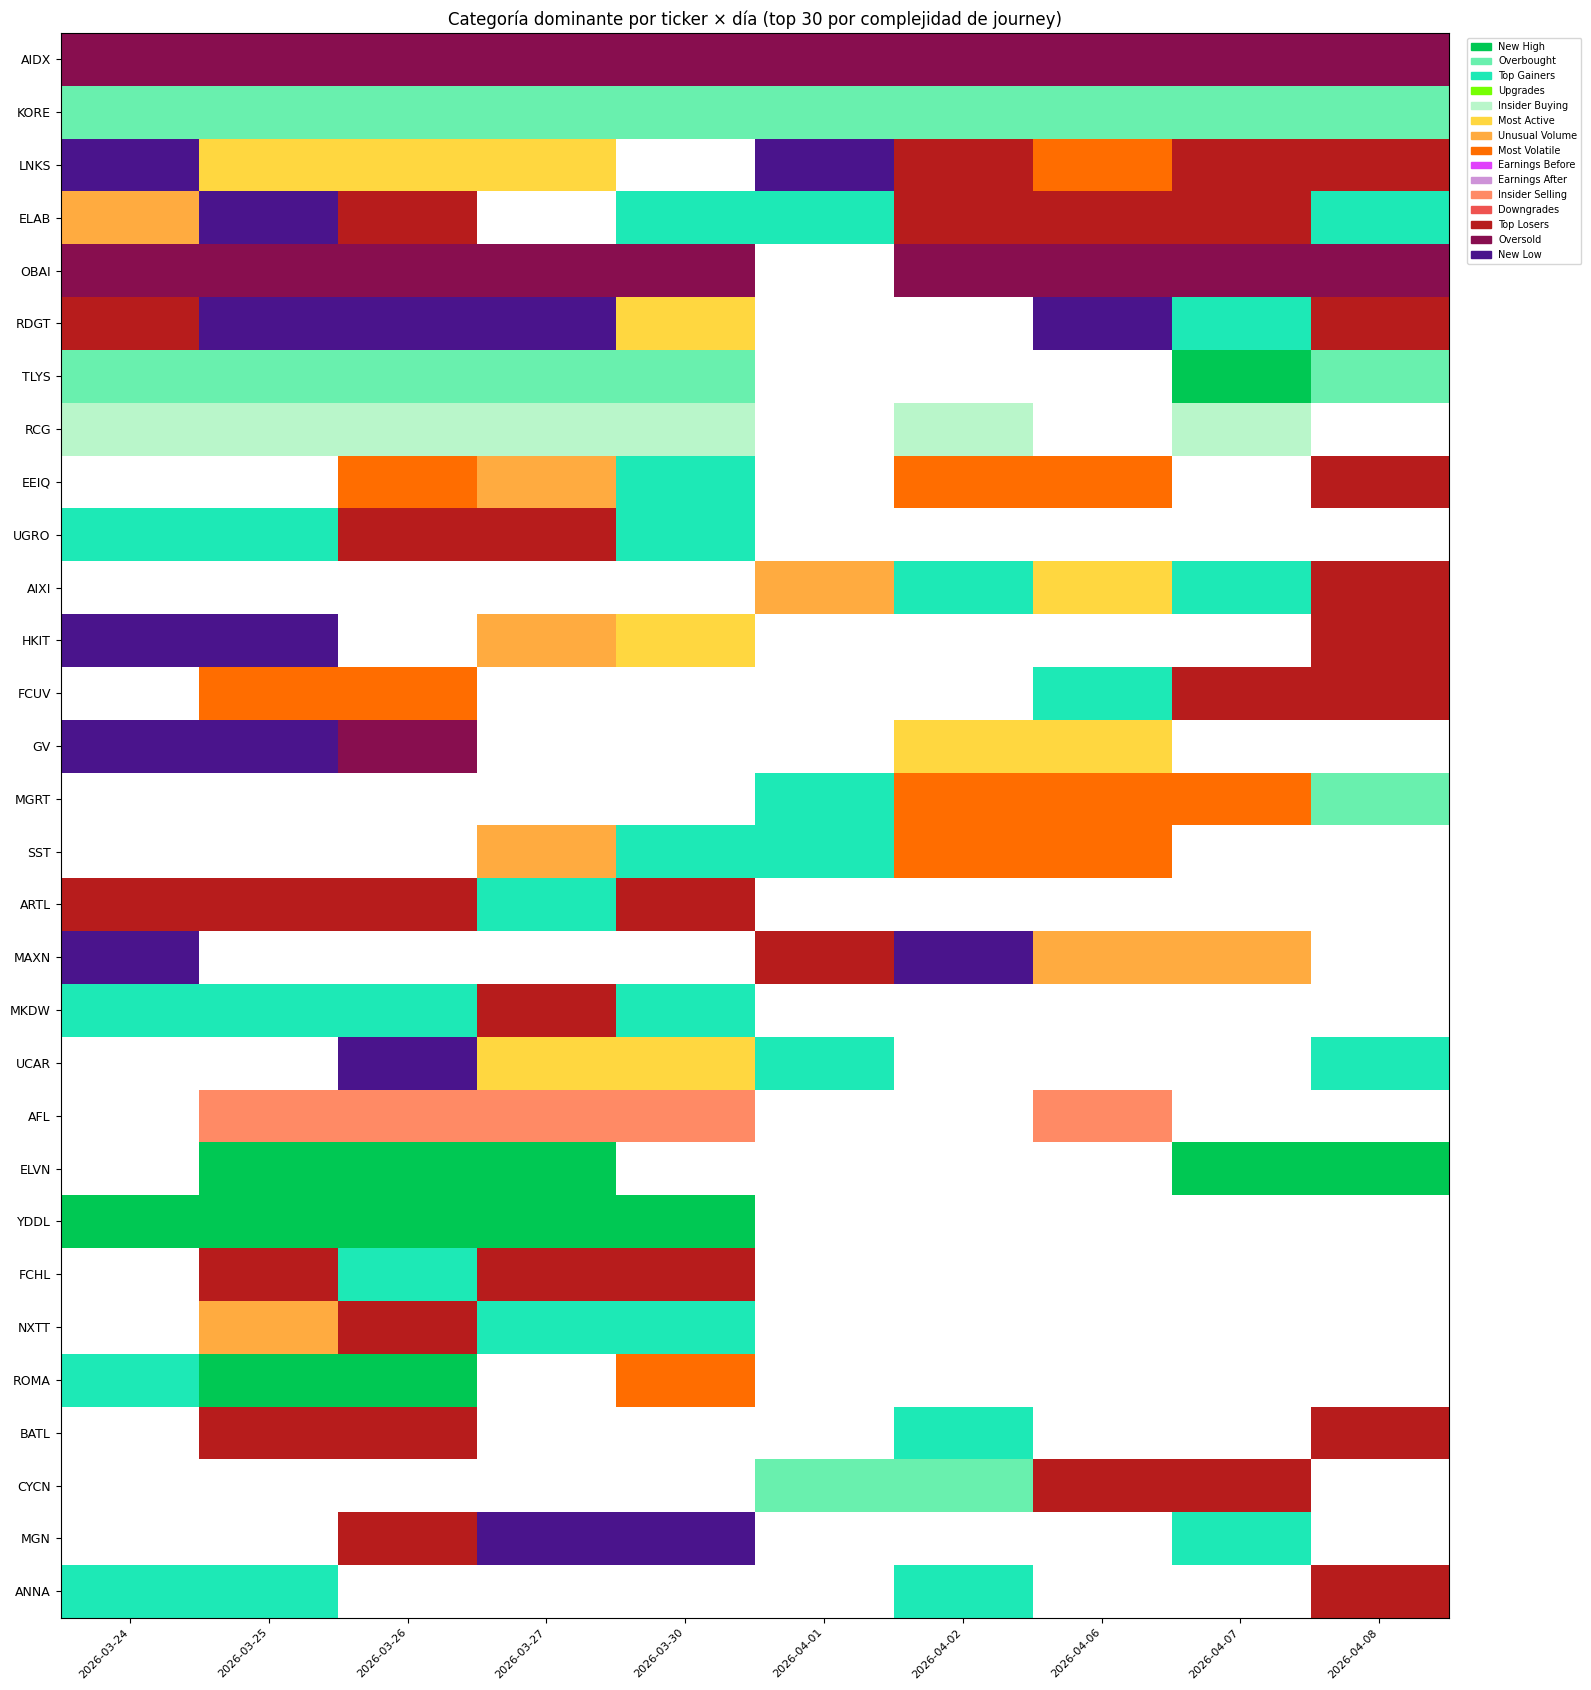

In [47]:
# Heatmap: top 30 tickers × días con color por categoría dominante del día
# (categoría con más snapshots ese día)

top_tickers = top_journey['ticker'].head(30).tolist()
all_dates = sorted(raw['date'].unique())

# Categoría dominante por (ticker, día)
dom_cat = (daily[daily['ticker'].isin(top_tickers)]
           .sort_values('n', ascending=False)
           .groupby(['ticker','date'])
           .first()
           .reset_index()[['ticker','date','category']])

pivot = dom_cat.pivot(index='ticker', columns='date', values='category')
pivot = pivot.reindex(index=top_tickers)

# Convertir a numérico para colores
cat_idx = {c: i for i, c in enumerate(CAT_ORDER)}
num_pivot = pivot.applymap(lambda x: cat_idx.get(x, -1) if pd.notna(x) else np.nan)

fig, ax = plt.subplots(figsize=(max(16, len(all_dates)*0.9), len(top_tickers)*0.5 + 2))

colors_list = [CAT_COLOR.get(c, '#cccccc') for c in CAT_ORDER]
cmap = mcolors.ListedColormap(colors_list)
bounds = list(range(len(CAT_ORDER)+1))
norm = mcolors.BoundaryNorm(bounds, cmap.N)

im = ax.imshow(num_pivot.values, aspect='auto', cmap=cmap, norm=norm,
               interpolation='none')

ax.set_xticks(range(len(all_dates)))
ax.set_xticklabels([str(d) for d in all_dates], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(top_tickers)))
ax.set_yticklabels(top_tickers, fontsize=9)
ax.set_title('Categoría dominante por ticker × día (top 30 por complejidad de journey)', fontsize=12)

# Leyenda
patches = [mpatches.Patch(color=CAT_COLOR.get(c,'#ccc'), label=c) for c in CAT_ORDER]
ax.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7, framealpha=0.8)

plt.tight_layout()
plt.show()

## 2. Análisis de transiciones de categoría (patrones secuenciales)

¿Qué secuencias de categorías preceden a movimientos fuertes?

Ejemplos de patrones a buscar:
- `Unusual Volume → Top Gainers → New High` (breakout)
- `Top Gainers → Top Losers` (fade / short)
- `New Low → Unusual Volume → Top Gainers` (reversal)
- `Insider Buying → New High` (smart money ahead of move)

In [48]:
# Construir secuencia de categorías por ticker (una entrada por día, categoría dominante)
dom_per_day = (daily.sort_values('n', ascending=False)
               .groupby(['ticker','date'])
               .first()
               .reset_index()[['ticker','date','category']])
dom_per_day = dom_per_day.sort_values(['ticker','date'])

# Extraer transiciones consecutivas
transitions = []
for ticker, grp in dom_per_day.groupby('ticker'):
    cats = grp['category'].tolist()
    dates = grp['date'].tolist()
    for i in range(len(cats)-1):
        transitions.append({
            'ticker': ticker,
            'from_cat': cats[i],
            'to_cat': cats[i+1],
            'from_date': dates[i],
            'to_date': dates[i+1],
        })

tr = pd.DataFrame(transitions)

# Frecuencia de cada transición
tr_counts = tr.groupby(['from_cat','to_cat']).size().reset_index(name='count')
tr_counts = tr_counts.sort_values('count', ascending=False)
print('Top 30 transiciones más frecuentes:')
print(tr_counts.head(30).to_string(index=False))

Top 30 transiciones más frecuentes:
       from_cat          to_cat  count
     Top Losers      Top Losers     36
    Top Gainers     Top Gainers     34
Insider Selling Insider Selling     30
       New High        New High     28
        New Low         New Low     22
       Oversold        Oversold     20
     Overbought      Overbought     19
 Unusual Volume  Unusual Volume     18
    Top Gainers      Top Losers     18
 Insider Buying  Insider Buying     16
     Top Losers     Top Gainers     10
  Most Volatile   Most Volatile      6
 Unusual Volume     Top Gainers      6
     Top Losers         New Low      6
       New High      Overbought      5
        New Low      Top Losers      5
    Top Gainers   Most Volatile      5
    Most Active     Most Active      5
        New Low     Top Gainers      4
 Unusual Volume         New Low      4
 Unusual Volume      Top Losers      3
        New Low  Unusual Volume      3
    Most Active      Top Losers      3
    Most Active     Top Gain

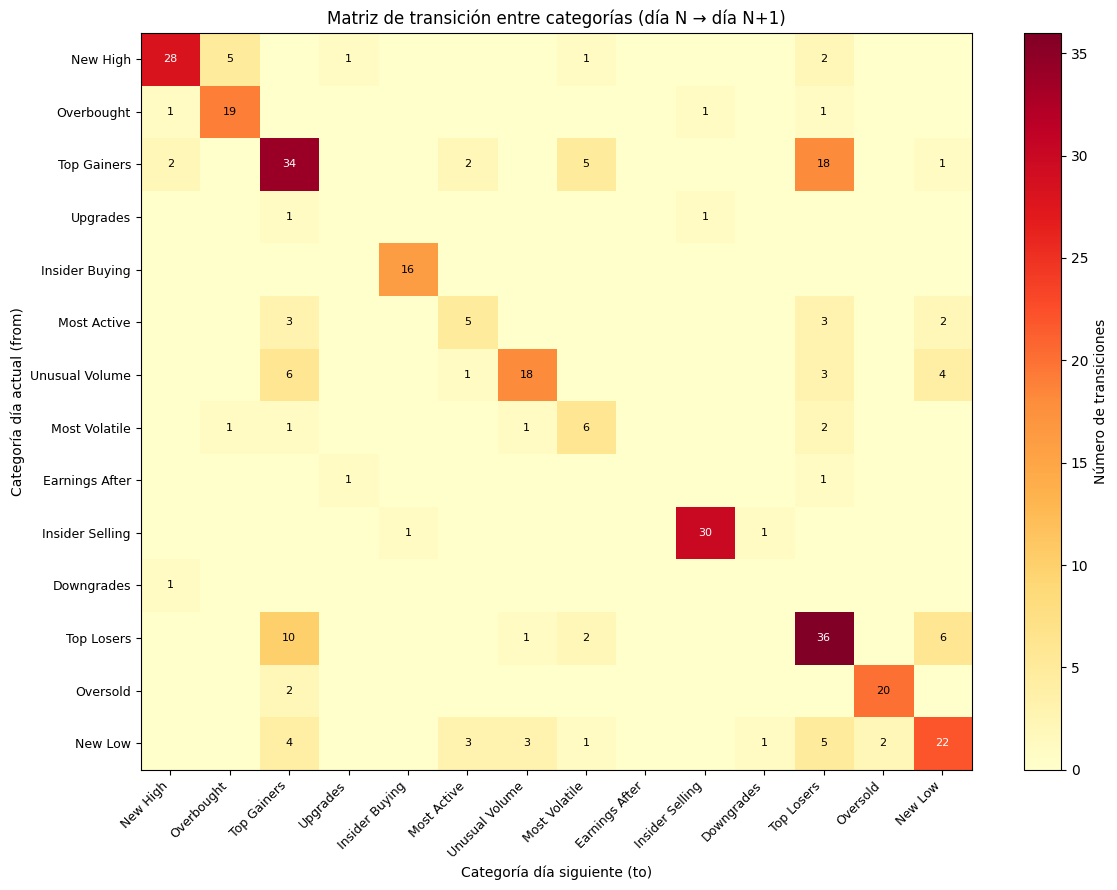

In [49]:
# Matriz de transición (heatmap)
cats_in_data = sorted(set(tr['from_cat'].unique()) | set(tr['to_cat'].unique()))
mat = tr_counts.pivot(index='from_cat', columns='to_cat', values='count').fillna(0)
mat = mat.reindex(index=[c for c in CAT_ORDER if c in cats_in_data],
                  columns=[c for c in CAT_ORDER if c in cats_in_data], fill_value=0)

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(mat.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(mat.columns)))
ax.set_xticklabels(mat.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(mat.index)))
ax.set_yticklabels(mat.index, fontsize=9)

for i in range(len(mat.index)):
    for j in range(len(mat.columns)):
        v = int(mat.values[i,j])
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center', fontsize=8,
                    color='white' if v > mat.values.max()*0.6 else 'black')

plt.colorbar(im, ax=ax, label='Número de transiciones')
ax.set_title('Matriz de transición entre categorías (día N → día N+1)', fontsize=12)
ax.set_xlabel('Categoría día siguiente (to)')
ax.set_ylabel('Categoría día actual (from)')
plt.tight_layout()
plt.show()

## 3. Patrones de co-movimiento entre tickers

¿Qué tickers aparecen juntos en los mismos snapshots repetidamente?
Si dos tickers co-aparecen con frecuencia en la misma categoría, puede indicar correlación por sector/tema.

In [50]:
# Por snapshot: qué tickers aparecen juntos en la misma categoría
# Enfocamos en categorías de señal (no Most Active que es muy ruidosa)
SIGNAL_CATS = ['Top Gainers', 'Unusual Volume', 'New High', 'Insider Buying', 'Upgrades',
               'Top Losers', 'New Low', 'Insider Selling', 'Downgrades']

sig = raw[raw['category'].isin(SIGNAL_CATS)].copy()

# Pares que co-aparecen en el mismo snapshot × categoría
co_pairs = defaultdict(int)
for (snap, cat), grp in sig.groupby(['snap','category']):
    tickers = grp['ticker'].unique()
    if len(tickers) >= 2:
        for t1, t2 in combinations(sorted(tickers), 2):
            co_pairs[(t1, t2, cat)] += 1

co_df = pd.DataFrame([
    {'ticker1': k[0], 'ticker2': k[1], 'category': k[2], 'co_snaps': v}
    for k, v in co_pairs.items()
]).sort_values('co_snaps', ascending=False)

print('Top 30 pares co-aparecientes en la misma categoría:')
print(co_df.head(30).to_string(index=False))

Top 30 pares co-aparecientes en la misma categoría:
ticker1 ticker2       category  co_snaps
    MGN    RDGT        New Low        33
   INHD    JTAI        New Low        29
   LNKS    MAXN        New Low        27
   FCUV    PFSA Unusual Volume        26
   HCAI    KPRX Unusual Volume        26
   FCHL     KOD    Top Gainers        26
   EEIQ     KOD    Top Gainers        26
   EEIQ    FCHL    Top Gainers        26
   ICCM    RDGT        New Low        26
   FEED    RBNE    Top Gainers        26
   AEHR    MGRT       New High        26
   FCUV    HUIZ Unusual Volume        26
   HUIZ    PFSA Unusual Volume        26
     JZ    RDGT     Top Losers        26
   SKYQ    TMDE    Top Gainers        26
   IPST    KPRX Unusual Volume        26
   ELAB     INO     Top Losers        26
   HCAI    IPST Unusual Volume        26
   CMBM     WVE     Top Losers        26
   PFSA     SMX     Top Losers        26
   FCUV     SMX     Top Losers        26
   ELAB    LNKS     Top Losers        26
   FC

In [51]:
# Pares más frecuentes (sumando todas las categorías)
co_total = co_df.groupby(['ticker1','ticker2'])['co_snaps'].sum().reset_index()
co_total = co_total.sort_values('co_snaps', ascending=False)
print('Top 20 pares más correlacionados (todas las categorías):')
print(co_total.head(20).to_string(index=False))

print('\nPares en Top Gainers:')
print(co_df[co_df['category']=='Top Gainers'].head(10).to_string(index=False))

print('\nPares en Unusual Volume:')
print(co_df[co_df['category']=='Unusual Volume'].head(10).to_string(index=False))

Top 20 pares más correlacionados (todas las categorías):
ticker1 ticker2  co_snaps
   FCUV    PFSA        78
   LNKS    LPCN        52
   LNKS    MAXN        51
   PFSA     SMX        50
   BFRG    ITRM        50
   COCP    SKYQ        50
   FCUV     SMX        50
   ASTC    ITRM        49
   ASTC    BFRG        49
   BBGI    OMEX        48
   AIXI    RDGT        47
   LPCN    MAXN        47
    MGN    RDGT        46
   LNKS    RDGT        45
   BDRX    SKYQ        41
   AIIO    INHD        41
   BDRX    COCP        39
   EEIQ    FCHL        36
    KOD    OLPX        35
   FCHL    GLND        34

Pares en Top Gainers:
ticker1 ticker2    category  co_snaps
   FCHL     KOD Top Gainers        26
   EEIQ     KOD Top Gainers        26
   EEIQ    FCHL Top Gainers        26
   FEED    RBNE Top Gainers        26
   SKYQ    TMDE Top Gainers        26
   AIXI    FCUV Top Gainers        26
   AIXI    PFSA Top Gainers        26
   AIXI    HCAI Top Gainers        26
   FCUV    PFSA Top Gainers     

## 3b. Interacción entre tickers el mismo día — Score matrix

Asignamos un score numérico a cada categoría (positivo = alcista, negativo = bajista)
y construimos una matriz `ticker × día`. Esto permite:
- Ver qué tickers se mueven en la misma dirección el mismo día
- Detectar lead-lag: si el movimiento de A hoy predice el de B mañana
- Identificar clusters de tickers que se comportan igual (sector/tema)

In [52]:
# Score numérico por categoría
CAT_SCORE = {
    'New High': 3, 'Overbought': 2, 'Top Gainers': 2, 'Upgrades': 1,
    'Insider Buying': 1, 'Most Active': 0, 'Unusual Volume': 0,
    'Most Volatile': 0, 'Earnings Before': 0, 'Earnings After': 0,
    'Downgrades': -1, 'Insider Selling': -1,
    'Top Losers': -2, 'Oversold': -2, 'New Low': -3
}

# Categoría dominante por ticker × día
daily_cat = (
    raw.groupby(['ticker','date','category']).size()
    .reset_index(name='n')
    .sort_values('n', ascending=False)
    .groupby(['ticker','date']).first()
    .reset_index()[['ticker','date','category']]
)
daily_cat['score'] = daily_cat['category'].map(CAT_SCORE).fillna(0)

# Pivot: ticker × fecha con score
score_pivot = daily_cat.pivot(index='ticker', columns='date', values='score')

# Solo tickers con >= 4 días activos
active_pivot = score_pivot[score_pivot.notna().sum(axis=1) >= 4].copy()
print(f'Tickers con >= 4 días activos: {len(active_pivot)}')
print()
print('Score matrix (filas=tickers, cols=días):')
print(active_pivot.to_string())

Tickers con >= 4 días activos: 35

Score matrix (filas=tickers, cols=días):
date    2026-03-24  2026-03-25  2026-03-26  2026-03-27  2026-03-30  2026-04-01  2026-04-02  2026-04-06  2026-04-07  2026-04-08
ticker                                                                                                                        
AFL            NaN        -1.0        -1.0        -1.0        -1.0         NaN         NaN        -1.0         NaN         NaN
AIDX          -2.0        -2.0        -2.0        -2.0        -2.0        -2.0        -2.0        -2.0        -2.0        -2.0
AIXI           NaN         NaN         NaN         NaN         NaN         0.0         2.0         2.0         2.0        -2.0
AMS            NaN         NaN         NaN         NaN         NaN        -2.0        -2.0        -2.0        -2.0         NaN
ANNA           2.0         2.0         NaN         NaN         NaN         NaN         2.0         NaN         NaN        -2.0
APA            3.0         NaN     

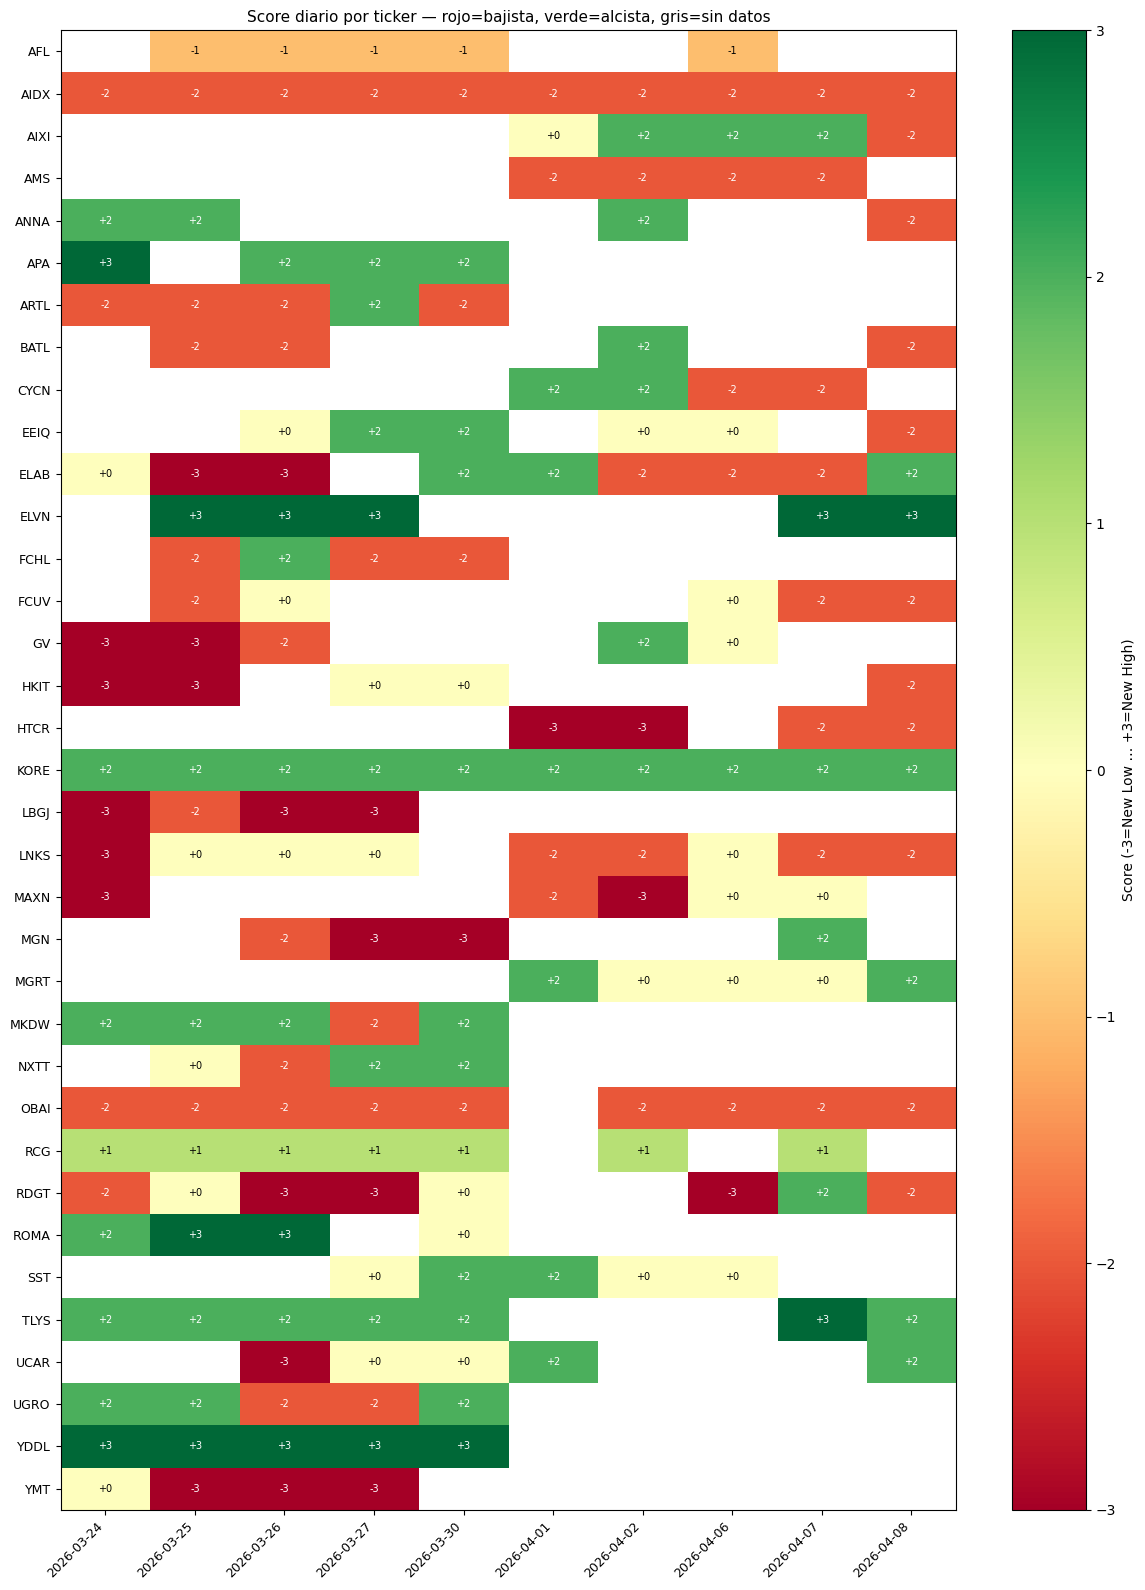

In [53]:
# Heatmap de la score matrix
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(max(12, len(active_pivot.columns)*1.2), len(active_pivot)*0.4 + 2))

cmap = plt.cm.RdYlGn
im = ax.imshow(active_pivot.values, cmap=cmap, vmin=-3, vmax=3, aspect='auto', interpolation='none')

ax.set_xticks(range(len(active_pivot.columns)))
ax.set_xticklabels([str(d) for d in active_pivot.columns], rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(active_pivot.index)))
ax.set_yticklabels(active_pivot.index, fontsize=9)

# Valores en celdas
for i in range(len(active_pivot.index)):
    for j in range(len(active_pivot.columns)):
        v = active_pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{int(v):+d}', ha='center', va='center', fontsize=7,
                    color='white' if abs(v) >= 2 else 'black')

plt.colorbar(im, ax=ax, label='Score (-3=New Low … +3=New High)')
ax.set_title('Score diario por ticker — rojo=bajista, verde=alcista, gris=sin datos', fontsize=11)
plt.tight_layout()
plt.show()

## 3c. Autocorrelación por ticker — ¿El score de hoy predice el de mañana?

Para cada ticker calculamos si su score en día N correlaciona con el score en día N+1.
- **Autocorr alta positiva** → momentum: si sube hoy, sube mañana
- **Autocorr alta negativa** → reversal: si sube hoy, baja mañana
- **Cercana a 0** → sin memoria, movimiento aleatorio

In [54]:
# Autocorrelación lag-1 por ticker
autocorr_results = []

for ticker in active_pivot.index:
    series = active_pivot.loc[ticker].dropna()
    if len(series) >= 4:
        # Lag-1: score[N] vs score[N+1]
        s = series.values
        lag1 = np.corrcoef(s[:-1], s[1:])[0,1] if len(s) > 2 else np.nan
        
        # Dirección dominante
        mean_score = series.mean()
        
        autocorr_results.append({
            'ticker': ticker,
            'n_days': len(series),
            'autocorr_lag1': round(lag1, 3) if not np.isnan(lag1) else np.nan,
            'mean_score': round(mean_score, 2),
            'score_seq': list(series.values.astype(int)),
            'bias': 'MOMENTUM' if lag1 > 0.3 else ('REVERSAL' if lag1 < -0.3 else 'NEUTRAL'),
        })

ac_df = pd.DataFrame(autocorr_results).sort_values('autocorr_lag1', ascending=False)
print('Autocorrelación lag-1 por ticker:')
print(ac_df.to_string(index=False))

print(f'\nTickers con MOMENTUM (autocorr > 0.3):  {(ac_df["autocorr_lag1"] > 0.3).sum()}')
print(f'Tickers con REVERSAL (autocorr < -0.3): {(ac_df["autocorr_lag1"] < -0.3).sum()}')
print(f'Tickers NEUTRALES:                       {(ac_df["autocorr_lag1"].abs() <= 0.3).sum()}')

Autocorrelación lag-1 por ticker:
ticker  n_days  autocorr_lag1  mean_score                                score_seq     bias
  UCAR       5          0.700        0.20                         [-3, 0, 0, 2, 2] MOMENTUM
  CYCN       4          0.500        0.00                           [2, 2, -2, -2] MOMENTUM
  HTCR       4          0.500       -2.50                         [-3, -3, -2, -2] MOMENTUM
    GV       5          0.410       -1.20                       [-3, -3, -2, 2, 0] MOMENTUM
  EEIQ       6          0.327        0.33                      [0, 2, 2, 0, 0, -2] MOMENTUM
  MAXN       5          0.314       -1.60                       [-3, -2, -3, 0, 0] MOMENTUM
  HKIT       5          0.192       -1.60                       [-3, -3, 0, 0, -2]  NEUTRAL
  ELAB       9          0.030       -0.67         [0, -3, -3, 2, 2, -2, -2, -2, 2]  NEUTRAL
  UGRO       5          0.000        0.40                        [2, 2, -2, -2, 2]  NEUTRAL
   SST       5          0.000        0.80     

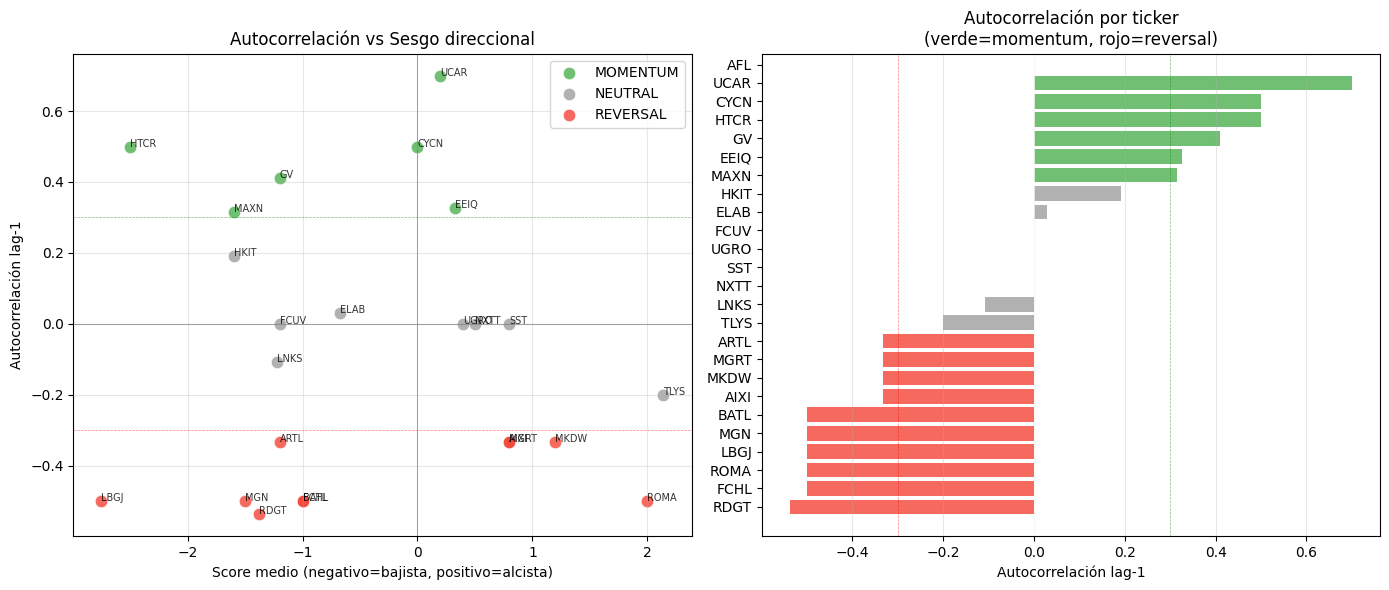

In [55]:
# Visualizar: scatter autocorr vs mean_score
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Scatter autocorr vs mean_score
colors_bias = {'MOMENTUM': '#4caf50', 'REVERSAL': '#f44336', 'NEUTRAL': '#9e9e9e'}
for bias, grp in ac_df.groupby('bias'):
    ax1.scatter(grp['mean_score'], grp['autocorr_lag1'],
               c=colors_bias[bias], label=bias, s=80, alpha=0.8, edgecolors='white', linewidths=0.5)
    for _, row in grp.iterrows():
        ax1.annotate(row['ticker'], (row['mean_score'], row['autocorr_lag1']),
                    fontsize=7, alpha=0.8)

ax1.axhline(0, color='gray', linewidth=0.5)
ax1.axhline(0.3, color='green', linewidth=0.5, linestyle='--', alpha=0.5)
ax1.axhline(-0.3, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
ax1.axvline(0, color='gray', linewidth=0.5)
ax1.set_xlabel('Score medio (negativo=bajista, positivo=alcista)')
ax1.set_ylabel('Autocorrelación lag-1')
ax1.set_title('Autocorrelación vs Sesgo direccional')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Barras de autocorrelación
ac_sorted = ac_df.sort_values('autocorr_lag1')
bar_colors = [colors_bias[b] for b in ac_sorted['bias']]
bars = ax2.barh(ac_sorted['ticker'], ac_sorted['autocorr_lag1'], color=bar_colors, alpha=0.8)
ax2.axvline(0, color='white', linewidth=0.5)
ax2.axvline(0.3, color='green', linewidth=0.5, linestyle='--', alpha=0.5)
ax2.axvline(-0.3, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
ax2.set_xlabel('Autocorrelación lag-1')
ax2.set_title('Autocorrelación por ticker\n(verde=momentum, rojo=reversal)')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 3d. Lead-lag entre pares de tickers — ¿A predice a B?

Para cada par de tickers, calculamos la correlación entre el score de A en día N
y el score de B en día N+1 (y N+2). Si es alta, A es un **leading indicator** de B.

Esto puede indicar:
- **Sector rotation**: cuando el líder del sector sube, los rezagados suben al día siguiente
- **Risk-on/risk-off**: un ticker macro (ej. PLTR) predice el comportamiento de smallcaps
- **Tema compartido**: dos biotech, dos EV, etc.

In [56]:
from itertools import combinations

# Solo tickers con >= 5 días para que la correlación tenga sentido
enough_days = active_pivot[active_pivot.notna().sum(axis=1) >= 5]
tickers_ll = enough_days.index.tolist()
print(f'Tickers para lead-lag (>= 5 días): {tickers_ll}')

lead_lag_results = []

for t_a, t_b in combinations(tickers_ll, 2):
    for lag in [1, 2]:  # A hoy predice B en lag días
        s_a = enough_days.loc[t_a]
        s_b = enough_days.loc[t_b]
        
        # Alinear: A en días 0..N-lag, B en días lag..N
        common = s_a.notna() & s_b.notna()
        dates = s_a.index[common]
        
        if len(dates) <= lag + 1:
            continue
        
        a_vals = s_a[dates].values[:-lag]
        b_vals = s_b[dates].values[lag:]
        
        if len(a_vals) < 3 or np.std(a_vals) == 0 or np.std(b_vals) == 0:
            continue
        
        corr = np.corrcoef(a_vals, b_vals)[0, 1]
        
        # También el inverso: B predice A
        a_vals2 = s_b[dates].values[:-lag]
        b_vals2 = s_a[dates].values[lag:]
        corr_inv = np.corrcoef(a_vals2, b_vals2)[0, 1] if np.std(a_vals2) > 0 and np.std(b_vals2) > 0 else np.nan
        
        lead_lag_results.append({
            'leader': t_a, 'follower': t_b, 'lag_days': lag,
            'corr': round(corr, 3), 'n_obs': len(a_vals)
        })
        lead_lag_results.append({
            'leader': t_b, 'follower': t_a, 'lag_days': lag,
            'corr': round(corr_inv, 3), 'n_obs': len(a_vals2)
        })

ll_df = pd.DataFrame(lead_lag_results).dropna(subset=['corr'])
ll_df = ll_df.sort_values('corr', ascending=False)

print(f'\nPares analizados: {len(ll_df)}')
print(f'\nTop 20 relaciones LEADER → FOLLOWER (corr > 0 = misma dirección):')
print(ll_df[ll_df['corr'] > 0.4].to_string(index=False))

print(f'\nTop relaciones INVERSAS (corr < 0 = dirección opuesta — potencial hedge):')
print(ll_df[ll_df['corr'] < -0.4].to_string(index=False))

Tickers para lead-lag (>= 5 días): ['AFL', 'AIDX', 'AIXI', 'ARTL', 'EEIQ', 'ELAB', 'ELVN', 'FCUV', 'GV', 'HKIT', 'KORE', 'LNKS', 'MAXN', 'MGRT', 'MKDW', 'OBAI', 'RCG', 'RDGT', 'SST', 'TLYS', 'UCAR', 'UGRO', 'YDDL']

Pares analizados: 129

Top 20 relaciones LEADER → FOLLOWER (corr > 0 = misma dirección):
leader follower  lag_days  corr  n_obs
  MGRT     LNKS         2 1.000      3
  ELAB     UCAR         1 1.000      3
  RDGT     FCUV         2 1.000      3
  RDGT     UCAR         1 1.000      3
  FCUV     TLYS         1 1.000      3
  AIXI     MAXN         1 1.000      3
  LNKS     EEIQ         2 1.000      3
  EEIQ     LNKS         2 1.000      3
  LNKS     MAXN         2 1.000      3
  MAXN     LNKS         2 1.000      3
  LNKS      SST         1 1.000      3
  LNKS     MGRT         2 1.000      3
  ELAB     LNKS         2 0.919      6
  LNKS       GV         2 0.866      3
  ELAB     TLYS         1 0.825      5
  RDGT     HKIT         2 0.756      3
  LNKS     HKIT         1 0.756 

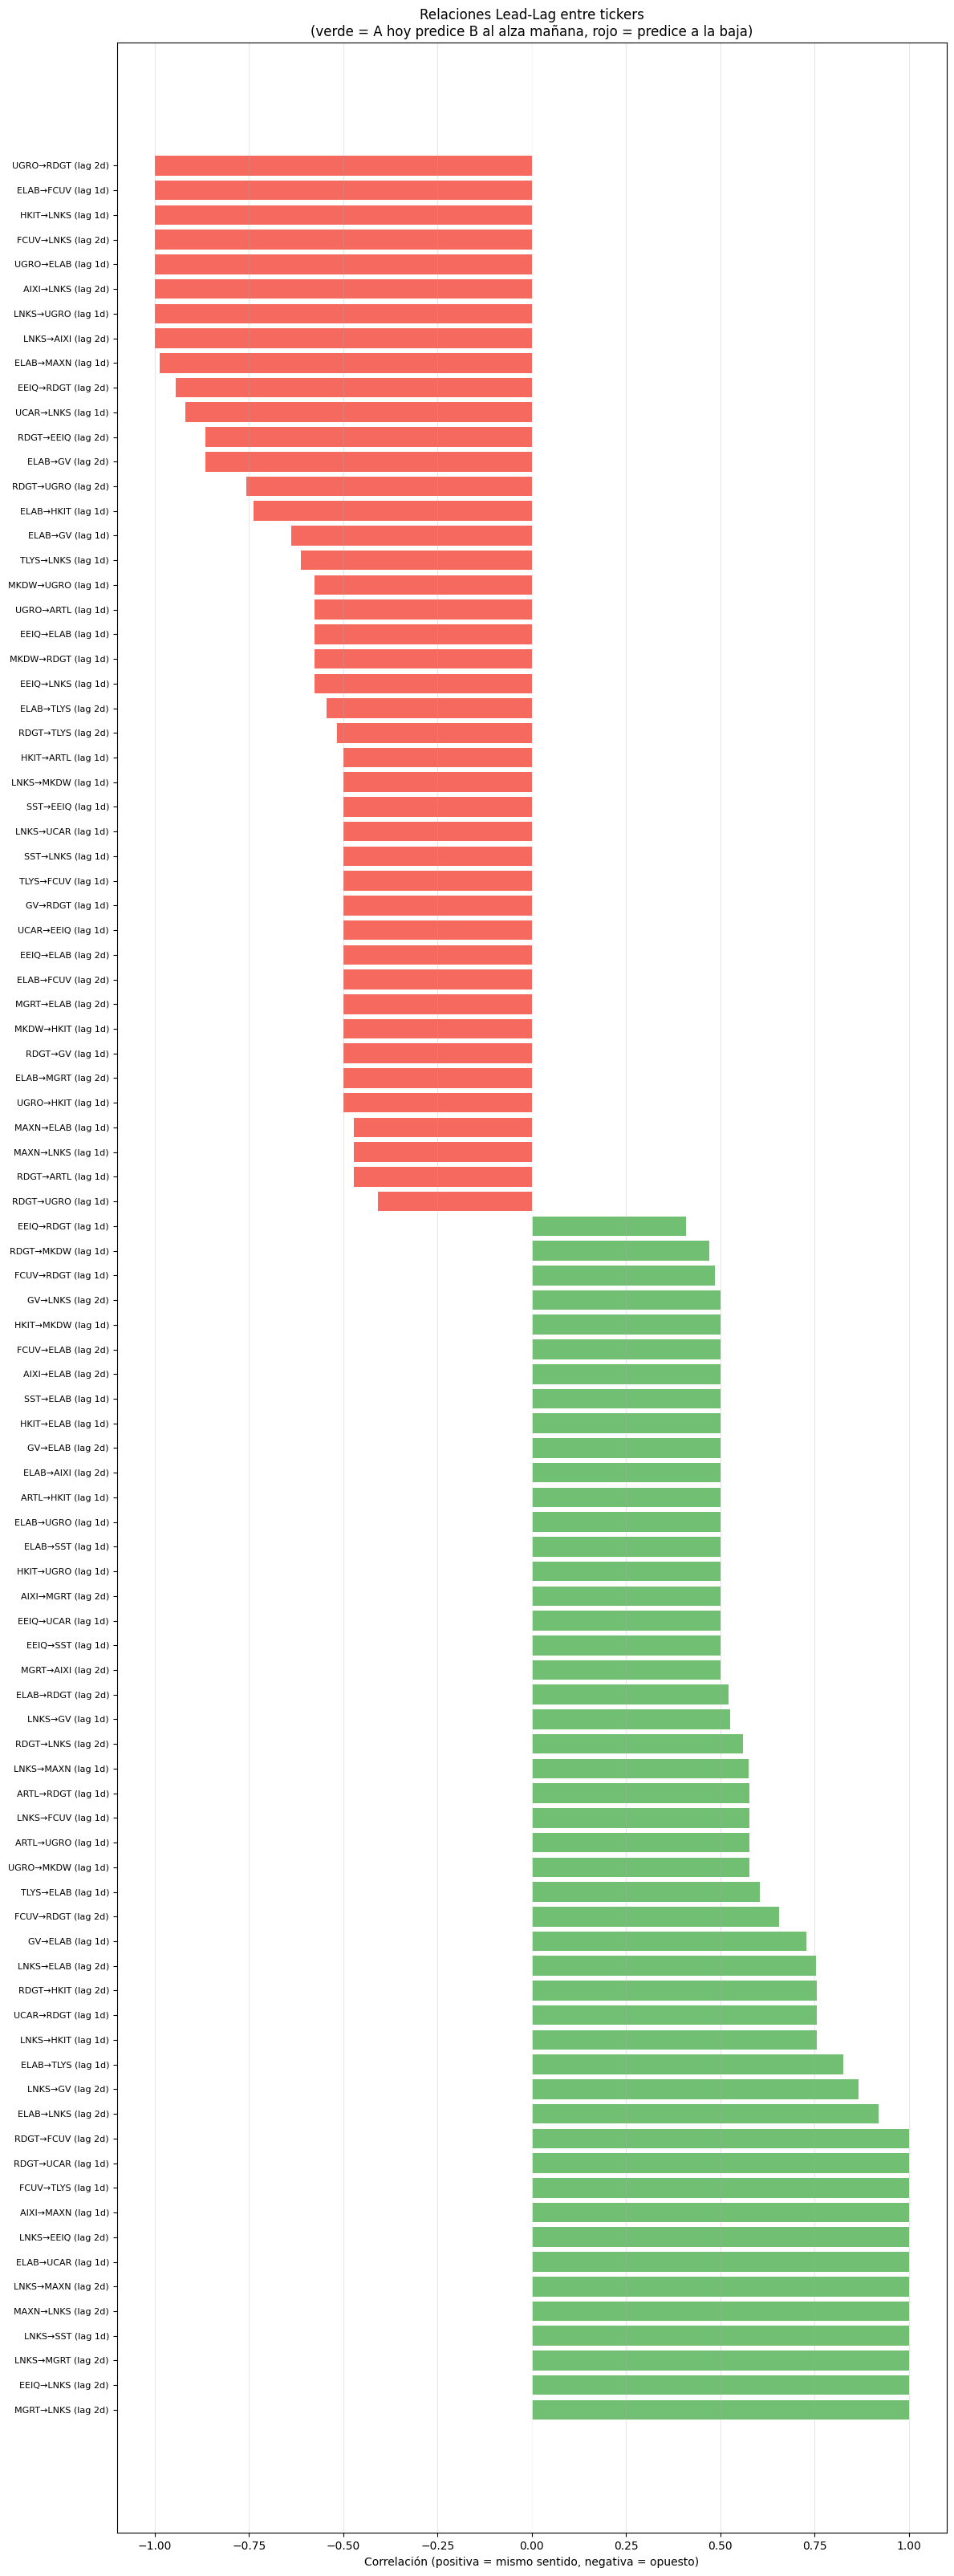

In [57]:
# Visualizar las relaciones de lead-lag más fuertes
top_ll = ll_df[ll_df['corr'].abs() > 0.4].sort_values('corr', ascending=False)

if top_ll.empty:
    print('No hay pares con correlación > 0.4 aún (dataset pequeño). Bajando umbral a 0.3...')
    top_ll = ll_df[ll_df['corr'].abs() > 0.3].sort_values('corr', ascending=False)

if not top_ll.empty:
    fig, ax = plt.subplots(figsize=(12, max(6, len(top_ll)*0.35)))
    
    labels = [f"{r['leader']}→{r['follower']} (lag {r['lag_days']}d)" for _, r in top_ll.iterrows()]
    colors_ll = ['#4caf50' if c > 0 else '#f44336' for c in top_ll['corr']]
    
    ax.barh(range(len(top_ll)), top_ll['corr'].values, color=colors_ll, alpha=0.8)
    ax.set_yticks(range(len(top_ll)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color='white', linewidth=0.5)
    ax.set_xlabel('Correlación (positiva = mismo sentido, negativa = opuesto)')
    ax.set_title('Relaciones Lead-Lag entre tickers\n(verde = A hoy predice B al alza mañana, rojo = predice a la baja)')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print('Dataset aún insuficiente para correlaciones robustas — seguir acumulando datos.')

## 3e. Clusters de tickers — ¿Quién se mueve junto?

Agrupamos tickers por similitud de comportamiento diario usando clustering jerárquico.
Los clusters pueden revelar grupos de sector o tema sin conocer el sector de cada ticker.

**Interpretación:**
- Tickers en el mismo cluster tienden a estar en las mismas categorías los mismos días
- Si un ticker del cluster da señal, los demás pueden seguirle

Tickers eliminados por varianza 0: 2  → quedan 33


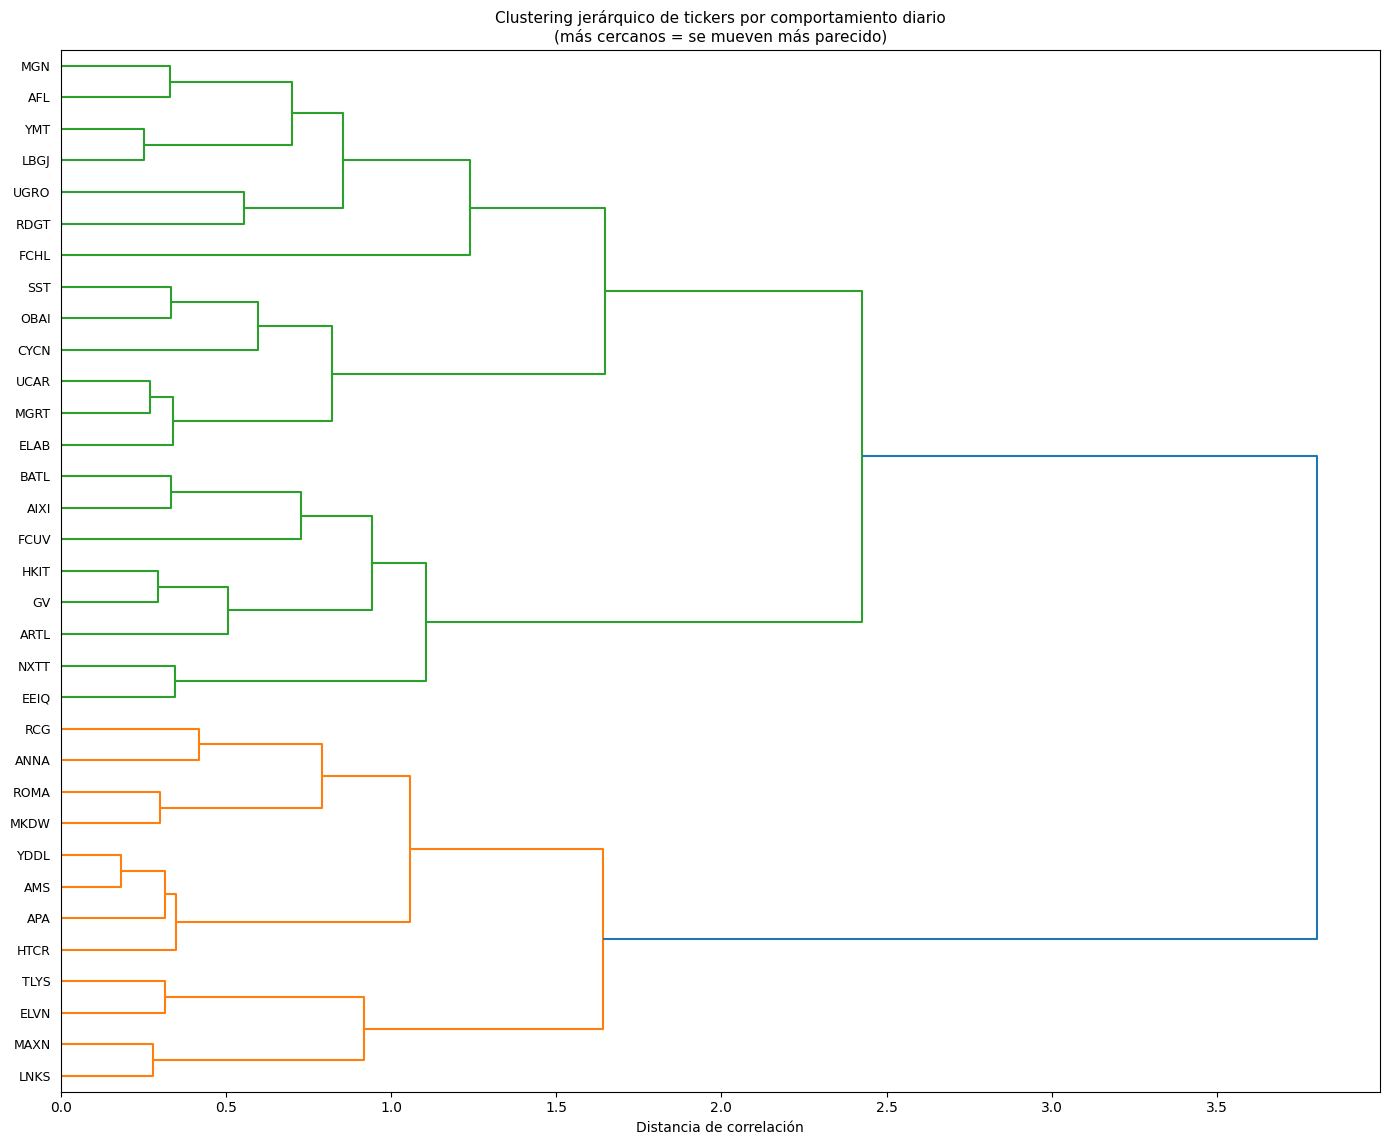


Asignación de 6 clusters:

  Cluster 1: ['ELVN', 'LNKS', 'MAXN', 'TLYS']
    Score medio por día: {datetime.date(2026, 3, 24): -1.0, datetime.date(2026, 3, 25): 1.2, datetime.date(2026, 3, 26): 1.2, datetime.date(2026, 3, 27): 1.2, datetime.date(2026, 3, 30): 0.5, datetime.date(2026, 4, 1): -1.0, datetime.date(2026, 4, 2): -1.2, datetime.date(2026, 4, 6): 0.0, datetime.date(2026, 4, 7): 1.0, datetime.date(2026, 4, 8): 0.8}

  Cluster 2: ['AMS', 'ANNA', 'APA', 'HTCR', 'MKDW', 'RCG', 'ROMA', 'YDDL']
    Score medio por día: {datetime.date(2026, 3, 24): 1.6, datetime.date(2026, 3, 25): 1.4, datetime.date(2026, 3, 26): 1.4, datetime.date(2026, 3, 27): 0.5, datetime.date(2026, 3, 30): 1.0, datetime.date(2026, 4, 1): -0.6, datetime.date(2026, 4, 2): -0.2, datetime.date(2026, 4, 6): -0.2, datetime.date(2026, 4, 7): -0.4, datetime.date(2026, 4, 8): -0.5}

  Cluster 3: ['AIXI', 'ARTL', 'BATL', 'EEIQ', 'FCUV', 'GV', 'HKIT', 'NXTT']
    Score medio por día: {datetime.date(2026, 3, 24): -1.0, dat

In [58]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# Rellenar NaN con 0 (no aparece = neutro)
cluster_data = active_pivot.fillna(0)

# Eliminar tickers con varianza 0 (scores constantes — correlación indefinida)
var_mask = cluster_data.var(axis=1) > 0
cluster_data = cluster_data[var_mask]
print(f'Tickers eliminados por varianza 0: {(~var_mask).sum()}  → quedan {len(cluster_data)}')

if len(cluster_data) >= 4:
    dist_matrix = pdist(cluster_data.values, metric='correlation')

    # Reemplazar NaN/inf residuales (por seguridad)
    import numpy as np
    dist_matrix = np.nan_to_num(dist_matrix, nan=1.0, posinf=2.0)

    Z = linkage(dist_matrix, method='ward')

    fig, ax = plt.subplots(figsize=(14, max(8, len(cluster_data)*0.35)))

    dn = dendrogram(
        Z,
        labels=cluster_data.index.tolist(),
        orientation='right',
        ax=ax,
        color_threshold=0.8 * max(Z[:,2]),
        leaf_font_size=9,
    )
    ax.set_title('Clustering jerárquico de tickers por comportamiento diario\n'
                 '(más cercanos = se mueven más parecido)', fontsize=11)
    ax.set_xlabel('Distancia de correlación')
    plt.tight_layout()
    plt.show()

    # Asignar clusters con corte
    n_clusters = min(6, len(cluster_data)//2)
    cluster_labels = fcluster(Z, n_clusters, criterion='maxclust')
    cluster_data_copy = cluster_data.copy()
    cluster_data_copy['cluster'] = cluster_labels

    print(f'\nAsignación de {n_clusters} clusters:')
    for c in range(1, n_clusters+1):
        members = cluster_data_copy[cluster_data_copy['cluster']==c].index.tolist()
        mean_scores = cluster_data.loc[members].mean().round(1).to_dict()
        print(f'\n  Cluster {c}: {members}')
        print(f'    Score medio por día: {mean_scores}')
else:
    print('Necesitas al menos 4 tickers con varianza > 0 para clustering.')


## 3f. Contagio de señal — cuando un ticker rompe, ¿arrastra a otros del mismo grupo?

Tomamos los eventos de transición fuerte (score sube >= 4 puntos de un día a otro)
y miramos si otros tickers que estaban en la misma categoría el día anterior
también suben al día siguiente.

In [59]:
# Detectar breakouts fuertes: score sube >= 3 en un día
breakout_events = []

dates_sorted = sorted(daily_cat['date'].unique())

for i in range(1, len(dates_sorted)):
    day_prev = dates_sorted[i-1]
    day_curr = dates_sorted[i]
    
    prev_scores = daily_cat[daily_cat['date']==day_prev].set_index('ticker')['score']
    curr_scores = daily_cat[daily_cat['date']==day_curr].set_index('ticker')['score']
    prev_cats   = daily_cat[daily_cat['date']==day_prev].set_index('ticker')['category']
    
    common = prev_scores.index.intersection(curr_scores.index)
    delta = curr_scores[common] - prev_scores[common]
    
    # Breakouts: delta >= 3 (ej. de New Low -3 a Top Gainers +2 = delta 5)
    for ticker in delta[delta >= 3].index:
        cat_before = prev_cats.get(ticker, 'N/A')
        cat_after = daily_cat[(daily_cat['date']==day_curr) & (daily_cat['ticker']==ticker)]['category'].values
        cat_after = cat_after[0] if len(cat_after) > 0 else 'N/A'
        
        # ¿Qué otros tickers estaban en la misma categoría el día anterior?
        peers = prev_cats[prev_cats == cat_before].index.tolist()
        peers = [p for p in peers if p != ticker]
        
        # ¿Cuántos de esos peers también subieron?
        peers_in_curr = [p for p in peers if p in curr_scores.index]
        peers_up = [p for p in peers_in_curr if delta.get(p, 0) > 0]
        
        breakout_events.append({
            'date': day_curr,
            'ticker': ticker,
            'from_cat': cat_before,
            'to_cat': cat_after,
            'score_delta': int(delta[ticker]),
            'n_peers': len(peers),
            'peers_up': len(peers_up),
            'contagion_rate': round(len(peers_up)/len(peers_in_curr), 2) if peers_in_curr else np.nan,
            'peer_list': peers[:5],  # primeros 5
        })

bo_df = pd.DataFrame(breakout_events)
if not bo_df.empty:
    print(f'Eventos de breakout fuerte (delta >= 3): {len(bo_df)}')
    print()
    print(bo_df[['date','ticker','from_cat','to_cat','score_delta','n_peers','peers_up','contagion_rate','peer_list']]
          .to_string(index=False))
    print()
    print(f'Tasa de contagio media: {bo_df["contagion_rate"].mean():.1%}')
    print(f'Breakouts con contagion > 50%: {(bo_df["contagion_rate"] > 0.5).sum()}')
else:
    print('No se detectaron breakouts fuertes en el período analizado.')

Eventos de breakout fuerte (delta >= 3): 17

      date ticker   from_cat         to_cat  score_delta  n_peers  peers_up  contagion_rate                      peer_list
2026-03-25   BIAF Top Losers    Top Gainers            4       15         1            0.17 [ACHV, AHMA, ARTL, BNGO, CNXC]
2026-03-25   LNKS    New Low    Most Active            3        9         1            0.25   [GV, HKIT, ISPC, LBGJ, MAXN]
2026-03-26   FCHL Top Losers    Top Gainers            4       13         1            0.17 [ACHV, AHMA, ARTL, AVXL, BATL]
2026-03-27   ARTL Top Losers    Top Gainers            4       14         1            0.14 [AVXL, BATL, CBUS, CMBM, DERM]
2026-03-27   NXTT Top Losers    Top Gainers            4       14         1            0.14 [ARTL, AVXL, BATL, CBUS, CMBM]
2026-03-27   UCAR    New Low    Most Active            3        9         0            0.00 [AKAN, CTSO, ELAB, ICCM, LBGJ]
2026-03-30   GLND Top Losers    Top Gainers            4       18         2            0.40  [

## 4. Detección de patrones de entrada LONG

Buscamos la secuencia:
1. Día(s) en `New Low` / `Oversold` / `Top Losers` (agotamiento bajista)
2. Aparición de `Unusual Volume` (acumulación)
3. Transición a `Top Gainers` / `New High` (breakout)

Este patrón es clásico de reversal después de capitulación.

In [60]:
BEAR_CATS = {'New Low', 'Oversold', 'Top Losers'}
VOLUME_CATS = {'Unusual Volume', 'Most Active'}
BULL_CATS = {'Top Gainers', 'New High', 'Overbought'}

reversal_candidates = []

for ticker, grp in dom_per_day.groupby('ticker'):
    cats_seq = grp[['date','category']].values.tolist()  # [[date, cat], ...]
    
    for i in range(1, len(cats_seq)):
        prev_cat = cats_seq[i-1][1]
        curr_cat = cats_seq[i][1]
        curr_date = cats_seq[i][0]
        
        # Patrón: bear → bull (reversal directo)
        if prev_cat in BEAR_CATS and curr_cat in BULL_CATS:
            reversal_candidates.append({
                'ticker': ticker,
                'pattern': 'BEAR→BULL',
                'from': prev_cat,
                'to': curr_cat,
                'signal_date': curr_date,
                'entry_day': curr_date,
            })
        
        # Patrón: bear → volume (acumulación)
        if prev_cat in BEAR_CATS and curr_cat in VOLUME_CATS:
            reversal_candidates.append({
                'ticker': ticker,
                'pattern': 'BEAR→VOLUME',
                'from': prev_cat,
                'to': curr_cat,
                'signal_date': curr_date,
                'entry_day': curr_date,
            })
        
        # Patrón: volume → bull (acumulación → breakout)
        if prev_cat in VOLUME_CATS and curr_cat in BULL_CATS:
            reversal_candidates.append({
                'ticker': ticker,
                'pattern': 'VOLUME→BULL',
                'from': prev_cat,
                'to': curr_cat,
                'signal_date': curr_date,
                'entry_day': curr_date,
            })

rev_df = pd.DataFrame(reversal_candidates)
print(f'Patrones de reversal detectados: {len(rev_df)}')
print()
print(rev_df.groupby('pattern').size().to_string())
print()
print(rev_df.to_string(index=False))

Patrones de reversal detectados: 32

pattern
BEAR→BULL      16
BEAR→VOLUME     7
VOLUME→BULL     9

ticker     pattern           from             to signal_date  entry_day
  AIXI VOLUME→BULL    Most Active    Top Gainers  2026-04-02 2026-04-02
  ARTL   BEAR→BULL     Top Losers    Top Gainers  2026-03-27 2026-03-27
  BATL   BEAR→BULL     Top Losers    Top Gainers  2026-04-02 2026-04-02
  BIAF   BEAR→BULL     Top Losers    Top Gainers  2026-03-25 2026-03-25
  COCP VOLUME→BULL Unusual Volume    Top Gainers  2026-04-06 2026-04-06
  ELAB   BEAR→BULL        New Low    Top Gainers  2026-03-30 2026-03-30
  ELAB   BEAR→BULL     Top Losers    Top Gainers  2026-04-08 2026-04-08
  FCHL   BEAR→BULL     Top Losers    Top Gainers  2026-03-26 2026-03-26
  GLND   BEAR→BULL     Top Losers    Top Gainers  2026-03-30 2026-03-30
    GV   BEAR→BULL       Oversold    Top Gainers  2026-04-02 2026-04-02
  HKIT BEAR→VOLUME        New Low Unusual Volume  2026-03-27 2026-03-27
  HUBC VOLUME→BULL Unusual Volume   

## 5. Detección de patrones de entrada SHORT

Buscamos la secuencia:
1. Ticker en `Top Gainers` / `New High` (momentum alcista)
2. Aparición de `Unusual Volume` sin confirmación de precio (distribución)
3. Transición a `Top Losers` / `Oversold` (fade)

También: `Overbought` varios días → reversal bajista.

In [61]:
fade_candidates = []

for ticker, grp in dom_per_day.groupby('ticker'):
    cats_seq = grp[['date','category']].values.tolist()
    
    for i in range(1, len(cats_seq)):
        prev_cat = cats_seq[i-1][1]
        curr_cat = cats_seq[i][1]
        curr_date = cats_seq[i][0]
        
        # Patrón: bull → bear (fade / short)
        if prev_cat in BULL_CATS and curr_cat in BEAR_CATS:
            fade_candidates.append({
                'ticker': ticker,
                'pattern': 'BULL→BEAR',
                'from': prev_cat,
                'to': curr_cat,
                'signal_date': curr_date,
            })
        
        # Patrón: overbought → cualquier bajista (exhaustion)
        if prev_cat == 'Overbought' and curr_cat in BEAR_CATS:
            fade_candidates.append({
                'ticker': ticker,
                'pattern': 'OVERBOUGHT→BEAR',
                'from': prev_cat,
                'to': curr_cat,
                'signal_date': curr_date,
            })

fade_df = pd.DataFrame(fade_candidates) if fade_candidates else pd.DataFrame()

if not fade_df.empty:
    print(f'Patrones de fade/short detectados: {len(fade_df)}')
    print()
    print(fade_df.groupby('pattern').size().to_string())
    print()
    print(fade_df.to_string(index=False))
else:
    print('No se detectaron patrones de fade (puede que el dataset sea aún pequeño)')

Patrones de fade/short detectados: 23

pattern
BULL→BEAR          22
OVERBOUGHT→BEAR     1

ticker         pattern        from         to signal_date
  AIXI       BULL→BEAR Top Gainers Top Losers  2026-04-08
  ANNA       BULL→BEAR Top Gainers Top Losers  2026-04-08
  ARTL       BULL→BEAR Top Gainers Top Losers  2026-03-30
  BATL       BULL→BEAR Top Gainers Top Losers  2026-04-08
  BFRG       BULL→BEAR Top Gainers Top Losers  2026-04-02
  CETX       BULL→BEAR Top Gainers Top Losers  2026-04-08
  CYCN       BULL→BEAR  Overbought Top Losers  2026-04-06
  CYCN OVERBOUGHT→BEAR  Overbought Top Losers  2026-04-06
  ELAB       BULL→BEAR Top Gainers Top Losers  2026-04-02
  FCHL       BULL→BEAR Top Gainers Top Losers  2026-03-27
  GCTK       BULL→BEAR Top Gainers    New Low  2026-03-30
  GLND       BULL→BEAR Top Gainers Top Losers  2026-03-27
  GRNQ       BULL→BEAR    New High Top Losers  2026-04-06
  MKDW       BULL→BEAR Top Gainers Top Losers  2026-03-27
   MTC       BULL→BEAR    New High Top

## 6. Visualización del journey individual

Gráfico detallado del recorrido de un ticker específico: precio + cambio % + categorías activas a lo largo del tiempo.

Modifica `TICKER` para explorar cualquier ticker del dataset.

In [62]:
def plot_ticker_journey(ticker_sym):
    t = raw[raw['ticker'] == ticker_sym].copy().sort_values('ts')
    if t.empty:
        print(f'{ticker_sym} no encontrado en el dataset')
        return
    
    print(f'=== {ticker_sym} ===')
    print(f'Período: {t["date"].min()} → {t["date"].max()}')
    print(f'Categorías: {sorted(t["category"].unique())}')
    print()
    
    # Resumen por día
    day_summary = t.groupby(['date','category']).agg(
        snaps=('id','count'),
        avg_price=('price','mean'),
        avg_chg=('chg','mean'),
        max_chg=('chg','max'),
        min_chg=('chg','min'),
    ).reset_index()
    print(day_summary.to_string(index=False))
    print()
    
    cats_present = sorted(t['category'].unique())
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
    fig.suptitle(f'{ticker_sym} — Journey análisis', fontsize=14)
    
    # Panel 1: Precio a lo largo del tiempo
    ax1 = axes[0]
    t_price = t.dropna(subset=['price'])
    ax1.plot(t_price['ts'], t_price['price'], 'o-', markersize=2, linewidth=1, color='#2196F3')
    ax1.set_ylabel('Precio ($)')
    ax1.set_title('Precio')
    ax1.grid(True, alpha=0.3)
    
    # Colorear fondo por categoría dominante
    dom = (t.groupby(['snap','category']).size()
             .reset_index(name='n')
             .sort_values('n', ascending=False)
             .groupby('snap').first().reset_index())
    dom['snap'] = pd.to_datetime(dom['snap'])
    for _, row in dom.iterrows():
        color = CAT_COLOR.get(row['category'], '#cccccc')
        ax1.axvspan(row['snap'], row['snap'] + pd.Timedelta('15min'), 
                   alpha=0.15, color=color, linewidth=0)
    
    # Panel 2: Change %
    ax2 = axes[1]
    t_chg = t.dropna(subset=['chg'])
    colors_chg = ['#4caf50' if c >= 0 else '#f44336' for c in t_chg['chg']]
    ax2.bar(t_chg['ts'], t_chg['chg'], width=0.008, color=colors_chg, alpha=0.7)
    ax2.axhline(0, color='white', linewidth=0.5)
    ax2.set_ylabel('Change %')
    ax2.set_title('Change % por snapshot')
    ax2.grid(True, alpha=0.3)
    
    # Panel 3: Presencia por categoría (gantt)
    ax3 = axes[2]
    y_positions = {cat: i for i, cat in enumerate(cats_present)}
    for _, row in t.iterrows():
        cat = row['category']
        y = y_positions[cat]
        color = CAT_COLOR.get(cat, '#888')
        ax3.barh(y, 0.01, left=mdates.date2num(row['ts'].to_pydatetime()) if hasattr(row['ts'], 'to_pydatetime') else 0,
                height=0.6, color=color, alpha=0.8)
    
    # Simplificado: scatter por categoría
    ax3.clear()
    for cat in cats_present:
        cat_data = t[t['category'] == cat]
        y = y_positions[cat]
        color = CAT_COLOR.get(cat, '#888')
        ax3.scatter(cat_data['ts'], [y]*len(cat_data), c=color, s=15, alpha=0.7, label=cat)
    
    ax3.set_yticks(range(len(cats_present)))
    ax3.set_yticklabels(cats_present, fontsize=9)
    ax3.set_title('Presencia por categoría')
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Importar mdates aquí si no está
import matplotlib.dates as mdates

# Explorar tickers con journeys interesantes
interesting = journey_stats[journey_stats['n_cats'] >= 4]['ticker'].tolist()
print(f'Tickers con >= 4 categorías distintas: {interesting}')

Tickers con >= 4 categorías distintas: ['AGX', 'AIXI', 'ASTC', 'BFRG', 'COCP', 'EEIQ', 'ELAB', 'FCHL', 'FCUV', 'GV', 'HKIT', 'INHD', 'ITRM', 'LNKS', 'MGRT', 'NXTT', 'OMEX', 'ONCO', 'PFSA', 'RDGT', 'ROMA', 'SKYQ', 'SMX', 'SNBR', 'SST', 'UGRO', 'VSA']


=== RDGT ===
Período: 2026-03-24 → 2026-04-08
Categorías: ['Most Active', 'Most Volatile', 'New Low', 'Top Gainers', 'Top Losers', 'Unusual Volume']

      date       category  snaps  avg_price    avg_chg  max_chg  min_chg
2026-03-24  Most Volatile      5   2.068000 -42.234000     0.00   -64.25
2026-03-24        New Low     17   0.281176 -92.164118   -82.96   -96.31
2026-03-24     Top Losers     25   0.544400 -84.814400   -34.35   -96.31
2026-03-24 Unusual Volume     16   0.213750 -94.062500   -89.21   -96.31
2026-03-25        New Low      1   0.130000   0.000000     0.00     0.00
2026-03-25     Top Losers      1   0.130000   0.000000     0.00     0.00
2026-03-25 Unusual Volume      1   0.130000   0.000000     0.00     0.00
2026-03-26        New Low     24   0.078750 -26.416250   -23.04   -31.48
2026-03-27        New Low     17   0.049412 -41.475882     0.00   -53.42
2026-03-27     Top Losers     15   0.045333 -45.667333   -33.61   -53.42
2026-03-30    Most Active      7   0.035714 -15

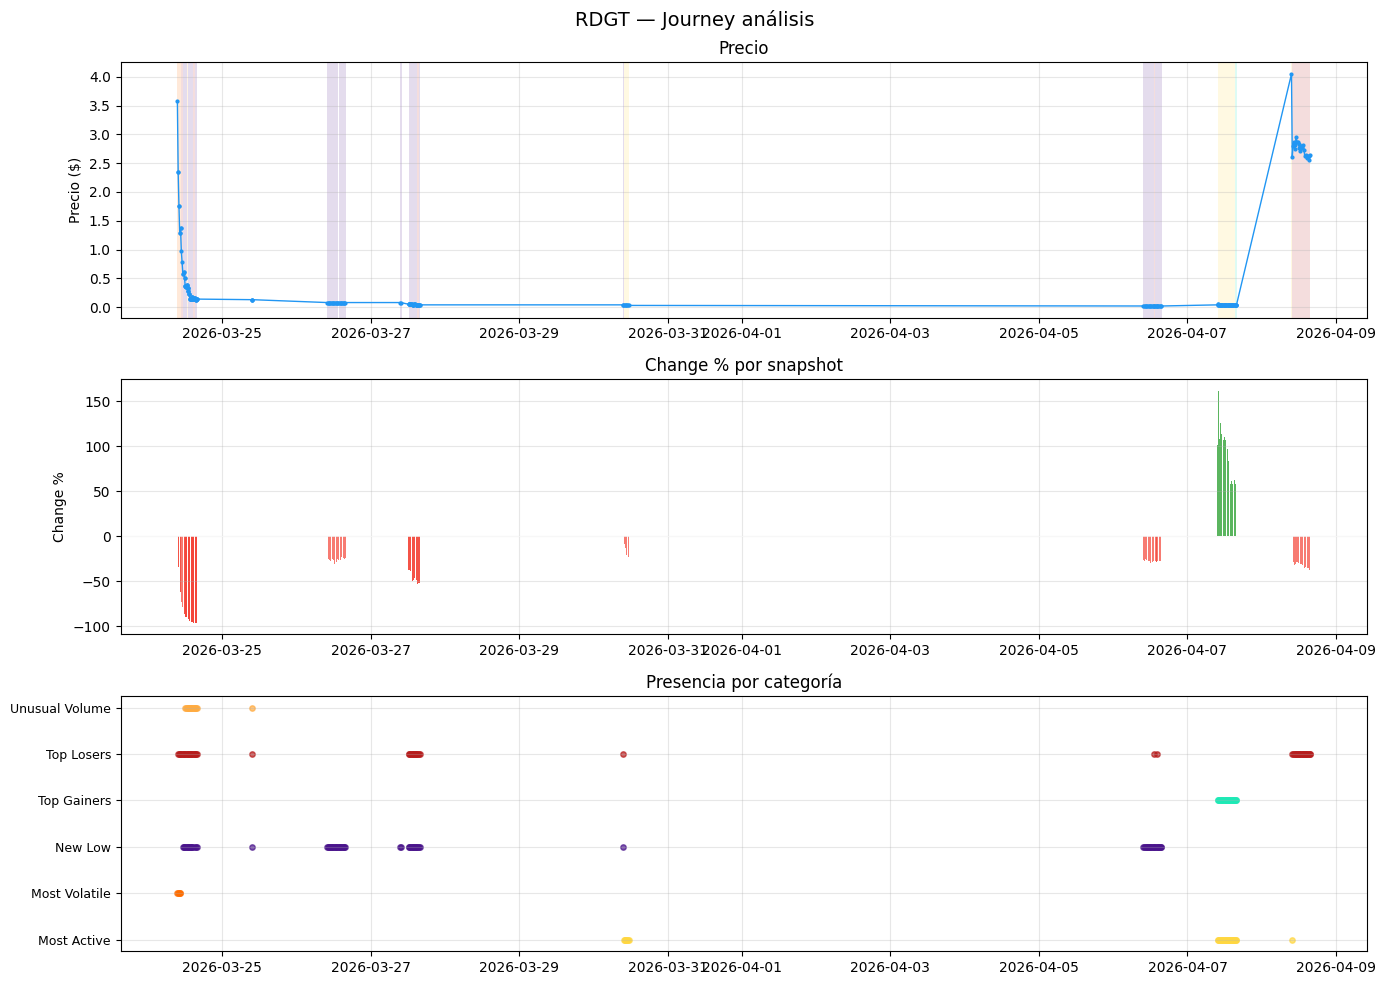

In [63]:
# Modificar TICKER para explorar cualquier ticker
TICKER = 'RDGT'  # <-- cambia aquí
plot_ticker_journey(TICKER)

In [64]:
# Ver todos los tickers con journeys interesantes de un vistazo
for t in interesting[:8]:
    print(f'\n--- {t} ---')
    sub = journey_stats[journey_stats['ticker']==t].iloc[0]
    print(f'  Días: {sub["days"]}, Cats: {sub["n_cats"]}, Bias: {sub["bias"]}')
    print(f'  Rango chg: {sub["min_chg"]:.1f}% → {sub["max_chg"]:.1f}% (avg {sub["avg_chg"]:.1f}%)')
    print(f'  Categorías: {sub["cats_str"]}')


--- AGX ---
  Días: 3, Cats: 4, Bias: BULLISH
  Rango chg: -8.4% → 40.4% (avg 22.9%)
  Categorías: Earnings After → New High → Top Gainers → Upgrades

--- AIXI ---
  Días: 5, Cats: 5, Bias: BULLISH
  Rango chg: -36.1% → 397.3% (avg 99.9%)
  Categorías: Most Active → Overbought → Top Gainers → Top Losers → Unusual Volume

--- ASTC ---
  Días: 1, Cats: 4, Bias: BULLISH
  Rango chg: 22.8% → 142.8% (avg 102.5%)
  Categorías: Most Volatile → Overbought → Top Gainers → Unusual Volume

--- BFRG ---
  Días: 2, Cats: 4, Bias: MIXED
  Rango chg: -29.9% → 189.2% (avg 141.1%)
  Categorías: Most Active → Top Gainers → Top Losers → Unusual Volume

--- COCP ---
  Días: 2, Cats: 4, Bias: BULLISH
  Rango chg: 0.0% → 80.0% (avg 44.5%)
  Categorías: Most Volatile → Overbought → Top Gainers → Unusual Volume

--- EEIQ ---
  Días: 6, Cats: 4, Bias: MIXED
  Rango chg: -32.9% → 306.6% (avg 163.2%)
  Categorías: Most Volatile → Top Gainers → Top Losers → Unusual Volume

--- ELAB ---
  Días: 9, Cats: 4, Bias: 

## 7. Análisis de momentum intradiario por categoría

¿Los tickers que aparecen en Top Gainers a las 9:30 siguen siendo gainers a las 15:00?
¿O revierten? Esto nos dice si el momentum es de apertura o de cierre.

In [65]:
# Para cada ticker + día: change% en apertura (9:30-10:00) vs cierre (15:00-16:00)
open_window = raw[(raw['hour'] == 9) | ((raw['hour'] == 10) & (raw['ts'].dt.minute < 15))].copy()
close_window = raw[raw['hour'] >= 15].copy()

open_chg = open_window.groupby(['ticker','date'])['chg'].mean().reset_index(name='open_chg')
close_chg = close_window.groupby(['ticker','date'])['chg'].mean().reset_index(name='close_chg')
open_cats = open_window.groupby(['ticker','date'])['category'].agg(lambda x: list(set(x))).reset_index(name='open_cats')

intraday = open_chg.merge(close_chg, on=['ticker','date']).merge(open_cats, on=['ticker','date'])
intraday['held'] = intraday['open_chg'] * intraday['close_chg'] > 0  # mismo signo
intraday['fade'] = intraday['open_chg'] > 0  # era positivo en apertura
intraday['reversal'] = intraday['open_chg'] < 0  # era negativo en apertura

print(f'Observaciones intradiarias (apertura + cierre mismo día): {len(intraday)}')
print(f'\n% que mantienen dirección (hold): {intraday["held"].mean()*100:.1f}%')

# ¿Los Top Gainers de apertura mantienen o revierten?
tg_open = intraday[intraday['open_cats'].apply(lambda x: 'Top Gainers' in x if isinstance(x, list) else False)]
if not tg_open.empty:
    print(f'\nTop Gainers en apertura → {len(tg_open)} observaciones')
    print(f'  Mantienen dirección al cierre: {tg_open["held"].mean()*100:.1f}%')
    print(f'  Change% apertura avg: {tg_open["open_chg"].mean():.1f}%')
    print(f'  Change% cierre avg:   {tg_open["close_chg"].mean():.1f}%')
    print(f'  Casos donde cierre > apertura (momentum): {(tg_open["close_chg"] > tg_open["open_chg"]).sum()}')
    print(f'  Casos donde cierre < apertura (fade):     {(tg_open["close_chg"] < tg_open["open_chg"]).sum()}')

Observaciones intradiarias (apertura + cierre mismo día): 201

% que mantienen dirección (hold): 78.6%

Top Gainers en apertura → 53 observaciones
  Mantienen dirección al cierre: 83.0%
  Change% apertura avg: 58.7%
  Change% cierre avg:   53.8%
  Casos donde cierre > apertura (momentum): 25
  Casos donde cierre < apertura (fade):     28


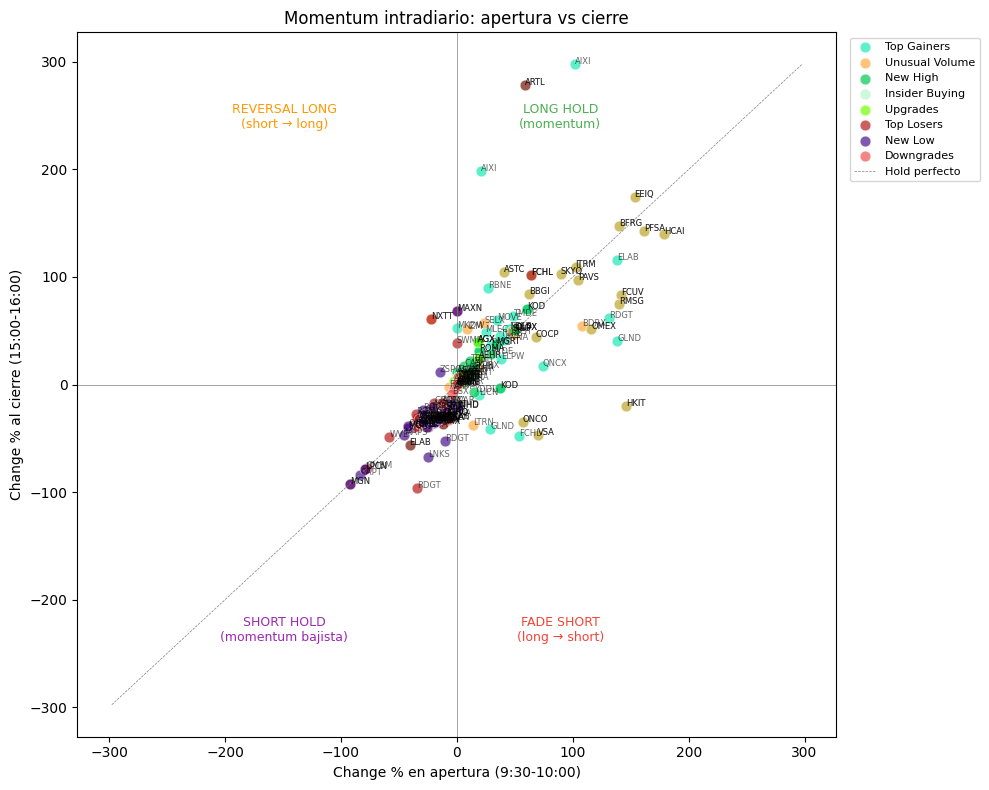

In [66]:
# Scatter: open_chg vs close_chg por ticker, coloreado por categoría de apertura
fig, ax = plt.subplots(figsize=(10, 8))

for cat in SIGNAL_CATS:
    sub = intraday[intraday['open_cats'].apply(lambda x: cat in x if isinstance(x, list) else False)]
    if not sub.empty:
        color = CAT_COLOR.get(cat, '#888')
        ax.scatter(sub['open_chg'], sub['close_chg'], 
                  c=color, label=cat, s=60, alpha=0.7, edgecolors='white', linewidths=0.5)
        for _, row in sub.iterrows():
            ax.annotate(row['ticker'], (row['open_chg'], row['close_chg']),
                       fontsize=6, alpha=0.6)

# Líneas de referencia
lim = max(abs(intraday['open_chg'].max()), abs(intraday['close_chg'].max()), 10)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.plot([-lim, lim], [-lim, lim], 'gray', linewidth=0.5, linestyle='--', label='Hold perfecto')

ax.set_xlabel('Change % en apertura (9:30-10:00)')
ax.set_ylabel('Change % al cierre (15:00-16:00)')
ax.set_title('Momentum intradiario: apertura vs cierre')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

# Cuadrantes
ax.text(lim*0.3, lim*0.8, 'LONG HOLD\n(momentum)', ha='center', color='#4caf50', fontsize=9)
ax.text(-lim*0.5, lim*0.8, 'REVERSAL LONG\n(short → long)', ha='center', color='#ff9800', fontsize=9)
ax.text(lim*0.3, -lim*0.8, 'FADE SHORT\n(long → short)', ha='center', color='#f44336', fontsize=9)
ax.text(-lim*0.5, -lim*0.8, 'SHORT HOLD\n(momentum bajista)', ha='center', color='#9c27b0', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Resumen de patrones con potencial edge

Tabla consolidada de los patrones más prometedores encontrados.

In [67]:
print('='*70)
print('RESUMEN DE PATRONES CON EDGE POTENCIAL')
print('='*70)

print('\n[LONG] Reversals detectados (bear → bull):')
if not rev_df.empty:
    long_rev = rev_df[rev_df['pattern']=='BEAR→BULL']
    for _, r in long_rev.iterrows():
        chg_info = raw[(raw['ticker']==r['ticker']) & (raw['date']==r['signal_date'])]['chg'].mean()
        print(f"  {r['ticker']:8s} {str(r['signal_date'])} : {r['from']:15s} → {r['to']:15s}  | chg_avg ese día: {chg_info:.1f}%")

print('\n[LONG] Acumulación detectada (bear → volume):')
if not rev_df.empty:
    accum = rev_df[rev_df['pattern']=='BEAR→VOLUME']
    for _, r in accum.iterrows():
        print(f"  {r['ticker']:8s} {str(r['signal_date'])} : {r['from']:15s} → {r['to']}")

print('\n[SHORT] Fades detectados (bull → bear):')
if not fade_df.empty:
    for _, r in fade_df[fade_df['pattern']=='BULL→BEAR'].iterrows():
        print(f"  {r['ticker']:8s} {str(r['signal_date'])} : {r['from']:15s} → {r['to']}")

print('\n[MULTI-LIST] Tickers con confluencia >= 3 categorías en mismo día:')
daily_cats = raw.groupby(['date','ticker'])['category'].apply(lambda x: set(x)).reset_index()
daily_cats['n'] = daily_cats['category'].apply(len)
strong = daily_cats[daily_cats['n'] >= 3].sort_values(['n','date'], ascending=[False,False])
for _, r in strong.head(20).iterrows():
    print(f"  {r['ticker']:8s} {str(r['date'])} : {r['n']} listas → {' | '.join(sorted(r['category']))}")

RESUMEN DE PATRONES CON EDGE POTENCIAL

[LONG] Reversals detectados (bear → bull):
  ARTL     2026-03-27 : Top Losers      → Top Gainers      | chg_avg ese día: 303.6%
  BATL     2026-04-02 : Top Losers      → Top Gainers      | chg_avg ese día: 31.8%
  BIAF     2026-03-25 : Top Losers      → Top Gainers      | chg_avg ese día: 21.5%
  ELAB     2026-03-30 : New Low         → Top Gainers      | chg_avg ese día: 108.2%
  ELAB     2026-04-08 : Top Losers      → Top Gainers      | chg_avg ese día: 42.2%
  FCHL     2026-03-26 : Top Losers      → Top Gainers      | chg_avg ese día: 80.9%
  GLND     2026-03-30 : Top Losers      → Top Gainers      | chg_avg ese día: 38.9%
  GV       2026-04-02 : Oversold        → Top Gainers      | chg_avg ese día: 119.1%
  ITRM     2026-03-30 : New Low         → Top Gainers      | chg_avg ese día: 99.5%
  MGN      2026-04-07 : New Low         → Top Gainers      | chg_avg ese día: 67.2%
  MKDW     2026-03-30 : Top Losers      → Top Gainers      | chg_avg ese d